In [1]:
import sys
import logging
from io import StringIO
logging.basicConfig()
sys.path.append('../src')

In [2]:
import numpy as np
from IPython.display import display
import polars as pl

In [3]:
# example data
df = pl.read_csv(StringIO("""time,temperature,weight
0,25,20.000
60,50,19.990
120,75,19.980
180,100,19.960
240,125,19.920
300,150,19.840
360,175,19.740
420,200,19.600
480,225,19.440
540,250,19.300
600,275,19.160
660,300,19.000
720,325,18.860
780,350,18.700
840,375,18.520
900,400,18.300
960,425,18.040
1020,450,17.760
1080,475,17.500
1140,500,17.200
1200,525,16.840
1260,550,16.500
1320,575,16.200
1380,600,15.960
1440,625,15.780
1500,650,15.640
1560,675,15.560
1620,700,15.500
1680,725,15.460
1740,750,15.420
1800,775,15.400"""))

In [4]:
# define data schema
from exptoolkit import data
class TGA(data.BaseData):
    # define name, base unit, role, and dtype of each column
    # amount that is proportional to sample amount is "EXTENSIVE."
    time = data.Column(base_unit='s', role=data.Role.INTENSIVE, dtype=pl.Float64)
    weight = data.Column(base_unit='mg', role=data.Role.EXTENSIVE, dtype=pl.Float64)
    temperature = data.Column(base_unit='degC', role=data.Role.INTENSIVE, dtype=pl.Float64)
    dtg = data.Column(base_unit='mg/s', role=data.Role.EXTENSIVE, dtype=pl.Float64)
TGA.schema

mappingproxy({'time': ColumnSpec(role=<Role.INTENSIVE: 0>, dtype=Float64, base_unit='s'),
              'weight': ColumnSpec(role=<Role.EXTENSIVE: 1>, dtype=Float64, base_unit='mg'),
              'temperature': ColumnSpec(role=<Role.INTENSIVE: 0>, dtype=Float64, base_unit='degC'),
              'dtg': ColumnSpec(role=<Role.EXTENSIVE: 1>, dtype=Float64, base_unit='mg/s')})

In [ ]:
# make data object
mydata = TGA(df)
# missing columns are automatically inserted
mydata.table

time,weight,temperature,dtg
f64,f64,f64,f64
0.0,20.0,25.0,null
60.0,19.99,50.0,null
120.0,19.98,75.0,null
180.0,19.96,100.0,null
240.0,19.92,125.0,null
…,…,…,…
1560.0,15.56,675.0,null
1620.0,15.5,700.0,null
1680.0,15.46,725.0,null


In [ ]:
# processing function
def differentiate(d: TGA):
    d.dtg = np.gradient(d.weight) / np.gradient(d.time)
differentiate(mydata)
mydata.table

# peak detection, baseline removal, ...

time,weight,temperature,dtg
f64,f64,f64,f64
0.0,20.0,25.0,-0.000167
60.0,19.99,50.0,-0.000167
120.0,19.98,75.0,-0.00025
180.0,19.96,100.0,-0.0005
240.0,19.92,125.0,-0.001
…,…,…,…
1560.0,15.56,675.0,-0.001167
1620.0,15.5,700.0,-0.000833
1680.0,15.46,725.0,-0.000667


In [23]:
# normalization
normdata = mydata.normalize(mydata.weight[0], 'mg')
normdata.table

time,weight,temperature,dtg
f64,f64,f64,f64
0.0,1.0,25.0,-0.000008
60.0,0.9995,50.0,-0.000008
120.0,0.999,75.0,-0.000012
180.0,0.998,100.0,-0.000025
240.0,0.996,125.0,-0.00005
…,…,…,…
1560.0,0.778,675.0,-0.000058
1620.0,0.775,700.0,-0.000042
1680.0,0.773,725.0,-0.000033


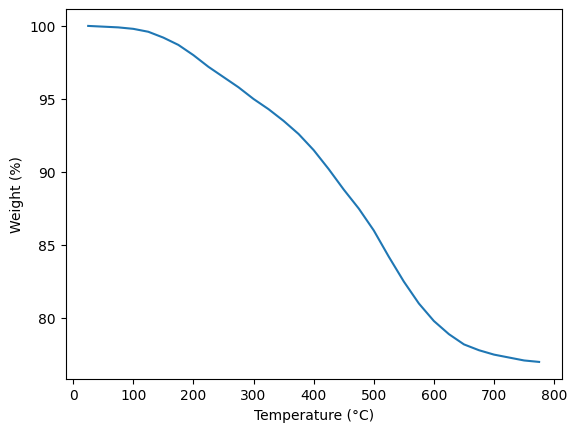

In [31]:
# plot using different backends
from exptoolkit.plotter import plot_xy

# Matplotlib
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('failed to import matplotlib. skipping.')
else:
    fig, ax = plt.subplots()
    plot_xy(normdata, ax, 'temperature', 'weight', yunit='%')
    plt.show()

# Plotly
try:
    from plotly import graph_objects as go
except ImportError:
    print('failed to import plotly. skipping')
else:
    fig = go.Figure()
    plot_xy(normdata, fig, 'temperature', 'weight', yunit='%')
    fig.show()

# OpenPyXl
try:
    from openpyxl import Workbook
    from openpyxl.chart import ScatterChart
except ImportError:
    print('failed to import openpyxl. skipping')
else:
    wb = Workbook()
    ws = wb.active
    chart = ScatterChart()
    plot_xy(normdata, (ws, chart), 'temperature', 'weight', label='my TGA data', yunit='%')
    ws.add_chart(chart, "A10")
    wb.save('tga_plot.xlsx')

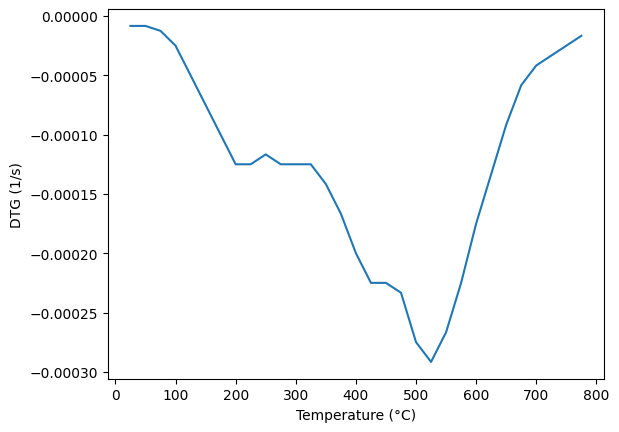

In [32]:
# defining data-specific plot
from exptoolkit.plotter import TargetLike, get_target

def plot_dtg(
    data: TGA,
    target_like: TargetLike,
):
    target = get_target(target_like)  # converts to exptoolkit.plotter.Target object
    target.add_line(data.temperature, data.dtg)
    target.set_ax_label("x", "Temperature (°C)")
    target.set_ax_label("y", f"DTG ({data.get_unit('dtg')})")
import matplotlib.pyplot as plt
plt.figure()
plot_dtg(normdata, plt.gca())